In [16]:
# Benchmark log bar plots
from pathlib import Path
import json
import numpy as np
import matplotlib.pyplot as plt

try:
    import pandas as pd
except ImportError:
    pd = None


In [28]:
# Collect all bench.jsonl files under inference_outputs
root = Path('/home/gaorory/Framediff/inference_outputs')
bench_files = sorted(root.glob('*/bench.jsonl'))
if not bench_files:
    raise FileNotFoundError(f'No bench.jsonl files found under {root}')

rows = []
for bf in bench_files:
    run_name = bf.parent.name
    with bf.open() as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            rec = json.loads(line)
            rec['run'] = run_name
            rows.append(rec)

if not rows:
    raise ValueError(f'No rows found in {bench_files}')

if pd is None:
    # Minimal fallback without pandas
    runs = sorted({r['run'] for r in rows})
    avg_wall = []
    avg_mem = []
    counts = []
    for run in runs:
        wr = [float(r.get('wall_time_ms')) for r in rows if r['run'] == run]
        mr = [float(r.get('max_gpu_mem_mb')) for r in rows if r['run'] == run]
        avg_wall.append(float(np.mean(wr)))
        avg_mem.append(float(np.mean(mr)))
        counts.append(len(wr))
else:
    df = pd.DataFrame(rows)
    grouped = df.groupby('run', as_index=False).agg(
        avg_wall_time_ms=('wall_time_ms', 'mean'),
        avg_max_gpu_mem_mb=('max_gpu_mem_mb', 'mean'),
        count=('sample_id', 'count'),
    )
    runs = grouped['run'].tolist()
    avg_wall = grouped['avg_wall_time_ms'].to_numpy() / 1000.
    avg_mem = grouped['avg_max_gpu_mem_mb'].to_numpy()
    counts = grouped['count'].to_numpy()

runs, avg_wall, avg_mem, counts


(['symm_efficient_n2000_c10',
  'symm_efficient_n2000_c20',
  'symm_efficient_n2000_c40',
  'symm_efficient_n2000_c5',
  'symm_n2000_c5'],
 array([159.06984767, 135.8132163 , 141.73687735, 222.22663159,
        707.05021143]),
 array([16524.65472412, 16352.60053711, 16265.55551758, 16871.67646484,
        35531.79833984]),
 array([ 8, 10, 10,  5,  3]))

In [29]:
runs

['symm_efficient_n2000_c10',
 'symm_efficient_n2000_c20',
 'symm_efficient_n2000_c40',
 'symm_efficient_n2000_c5',
 'symm_n2000_c5']

In [30]:
#Do not visualize symm_n2000_c5 for now
runs = [r for r in runs if r != 'symm_n2000_c5']
avg_wall = [w for r, w in zip(runs, avg_wall) if r != 'symm_n2000_c5']
avg_mem = [m for r, m in zip(runs, avg_mem) if r != 'symm_n2000_c5']

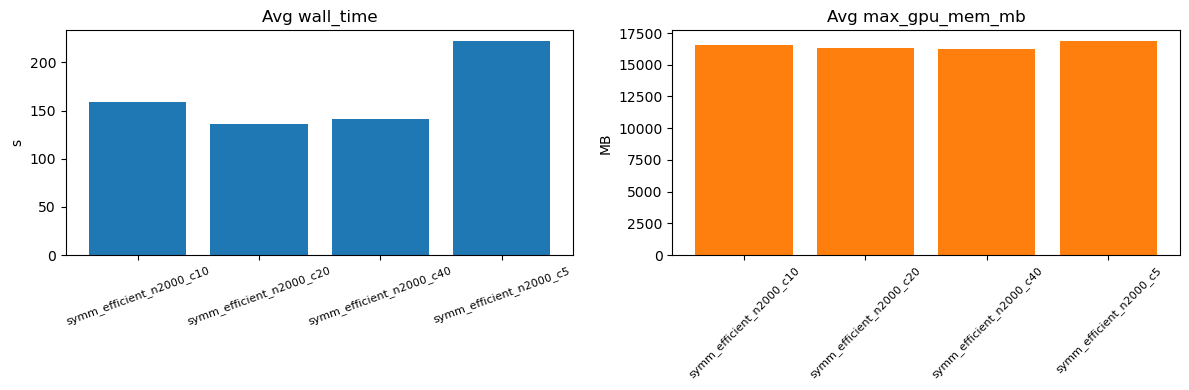

In [31]:
# Bar plots: average time and memory per run
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharex=True)

axes[0].bar(runs, avg_wall)
axes[0].set_title('Avg wall_time')
axes[0].set_ylabel('s')
axes[0].tick_params(axis='x', rotation=20, labelsize=8)

axes[1].bar(runs, avg_mem, color='tab:orange')
axes[1].set_title('Avg max_gpu_mem_mb')
axes[1].set_ylabel('MB')
axes[1].tick_params(axis='x', rotation=45, labelsize=8)

plt.tight_layout()
plt.show()
